# Paquete Software Matemático y Estadístico
**Autora:** Paula Azqueta Tamés  
**Fecha:** septiembre 2025  

Este notebook presenta el paquete `permupack`, un conjunto de utilidades didácticas que cubre tareas frecuentes del curso: creación y manejo de objetos, discretización y entropía, operaciones con matrices, permutaciones, visualización de correlaciones y evaluación con curvas ROC.  

Nuestro objetivo es ilustrar el uso práctico de cada bloque con ejemplos reproducibles.  
Para hacerlo más ameno, hemos inventado dos escenarios:  

- Una **carrera de drones**  
- Un **mini festival con 6 bandas de música**  

Este enfoque lúdico ayuda a que el aprendizaje sea más divertido y sencillo.

## 1. Resumen y Objetivos

Este documento presenta el paquete permupack, un conjunto de utilidades didácticas que cubre tareas frecuentes del curso: creación y manejo de objetos, discretización y entropía, operaciones con matrices, permutaciones, entrada/salida y registro (logging), visualización de correlaciones, evaluación con curvas ROC, recursividad y clases S4.Nuestro objetivo es ilustrar el uso práctico de cada bloque con ejemplos reproducibles, destacando buenas prácticas, decisiones típicas (p. ej., cuándo discretizar o normalizar) y errores comunes que conviene evitar.
Para hacer el código más ameno, me he inventado dos historias a aplicar dichas funcionalidades.
El primer ejemplo está basado en una **carrera de drones en un circuito de 100 km**.  
El segundo ejemplo consiste en un **mini festival de música con 6 bandas sonoras**.

Desde mi punto de vista, el aprendizaje se hace más divertido y entretenido si contamos las cosas con un enfoque más infantil, sencillo y lúdico. 
Espero que cumpla los requisitos de la entrega de este curso.

### 1.1 Materiales y Configuración
Todas las demostraciones se ejecutan en **Python** (versión `sys.version`) y dependen únicamente de los módulos declarados en nuestro paquete `permupack`.  

- Se configura una **semilla global** para garantizar la reproducibilidad de resultados.  
- Se definen **opciones globales** para gráficos (tamaño, estilo).  
- Cuando procede, se generan **datos de ejemplo en memoria** para no depender de ficheros externos.  
- En caso de usarse archivos, estos se gestionan mediante rutas relativas al paquete (`pkg_resources`) para asegurar **portabilidad** tras la instalación.  

## 2. Carrera de drones

Estas funciones son la capa de preprocesado más simple sobre la que se apoyan otros bloques (discretización, matrices, correlaciones). Aquí aclaramos cuándo conviene normalizar o estandarizar y cómo estas transformaciones influyen en pasos posteriores.

Imaginemos que organizamos una carrera de drones en un circuito de 100 km. Para analizar y practicar conceptos estadísticos (normalización, z-scores, correlaciones, etc.), representamos la carrera con una serie de supuestos:

  1. El recorrido está dividido en puntos de control cada 2 km (51 posiciones en total).
  2. Cada dron comienza con la batería al 100% en todos los puntos de control.
  3. Existen “bonus pit-stops” en las posiciones múltiplos de 7, donde se reparten premios o ventajas especiales. 


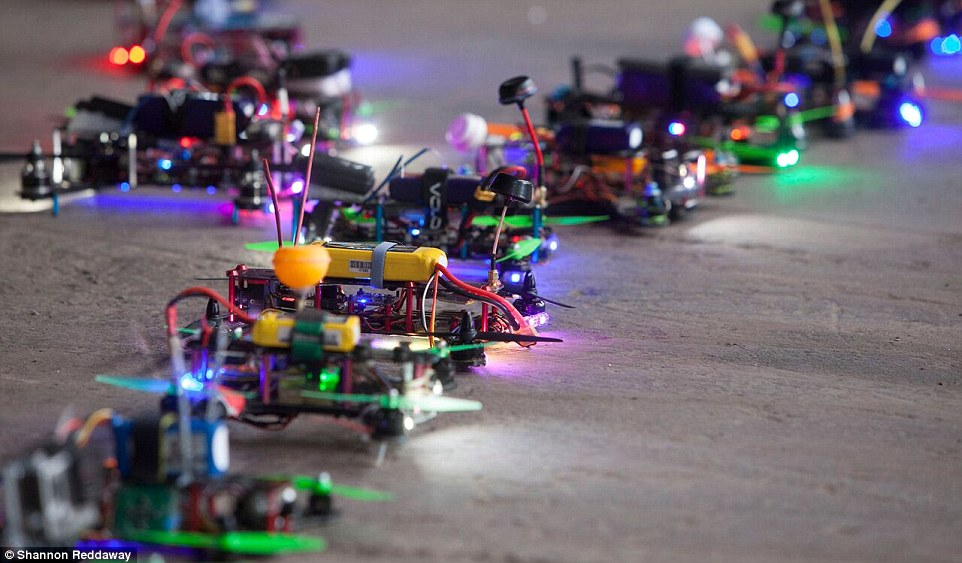

In [3]:
from IPython.display import Image
Image("images/drones.jpg")


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(123)
from perm_utils import sample_even

# Puntos de control
checkpoints = sample_even(max_par=100, k=10, replace=False, seed=42)
n = len(checkpoints)

# Estado inicial de batería
battery = np.repeat(100, n)
pos_labels = [f"Pos{i+1}" for i in range(n)]

# Bonus pit-stops
bonus_pts = checkpoints[checkpoints % 7 == 0]

# Velocidad media del dron (km/h)
speed_kmh = 30 + 5*np.sin(checkpoints/10) + np.random.normal(0, 1.2, n)

# Intensidad del público (dB, 0–1000)
cheers_db = 200 + 800*np.abs(np.cos(checkpoints/12)) + np.random.normal(0, 25, n)

df = pd.DataFrame({
    "pos": pos_labels,
    "km": checkpoints,
    "speed_kmh": np.round(speed_kmh, 2),
    "cheers_db": np.round(cheers_db, 1),
    "bonus": np.where(checkpoints % 7 == 0, "sí", "no")
})

df.head(8)

,pos,km,speed_kmh,cheers_db,bonus
0,Pos1,86,34.02,777.0,no
1,Pos2,80,34.18,971.7,no
2,Pos3,92,29.89,354.4,no
3,Pos4,24,33.18,555.0,no
4,Pos5,48,24.38,697.7,no
5,Pos6,62,29.58,511.5,no
6,Pos7,34,28.45,981.6,no
7,Pos8,64,31.05,652.0,no


#### Simulación de señales:
Para practicar normalización y z-scores, simulamos dos variables con escalas muy distintas:

  - speed_kmh: velocidad media del dron (km/h) con patrón suave + ruido;
  - cheers_db: intensidad del público (dB aprox. 0–1000) con patrón distinto + ruido.
  
Consultas típicas. Un ejemplo: ¿qué velocidad llevamos exactamente en los bonus pit-stops (múltiplos de 7 km)?

In [5]:
from perm_utils import normalize01, standardize

# Creamos dataframe principal
df = pd.DataFrame({
    "pos": pos_labels,
    "km": checkpoints,
    "speed_kmh": speed_kmh,
    "cheers_db": cheers_db
})

# --- 6) Consultas típicas ---
i_bonus = (df["km"] % 7 == 0)
df_bonus = df.loc[i_bonus, ["km", "speed_kmh"]].rename(columns={"km": "checkpoint_km",
                                                               "speed_kmh": "speed_bonus"})
# --- 7) Normalización y estandarización ---
  

df["cheers_norm"] = np.round(normalize01(df["cheers_db"]), 3)
df["speed_z"] = np.round(standardize(df["speed_kmh"]), 2)
df = df.round(2)


# --- 8) Propiedades esperadas ---
print("Rango de cheers_norm:", df["cheers_norm"].min(), "→", df["cheers_norm"].max())
print("Media de speed_z:", round(df["speed_z"].mean(), 6))   # ~ 0
print("Desviación estándar de speed_z:", round(df["speed_z"].std(ddof=0), 6)) # ~ 1

# Mostrar primeras filas
df.head(8)


Rango de cheers_norm: 0.0 → 1.0
Media de speed_z: -0.001
Desviación estándar de speed_z: 1.000374


,pos,km,speed_kmh,cheers_db,cheers_norm,speed_z
0,Pos1,86,34.02,777.03,0.67,1.23
1,Pos2,80,34.18,971.74,0.98,1.29
2,Pos3,92,29.89,354.44,0.00,-0.25
3,Pos4,24,33.18,554.96,0.32,0.93
4,Pos5,48,24.38,697.69,0.55,-2.24
5,Pos6,62,29.58,511.47,0.25,-0.37
6,Pos7,34,28.45,981.63,1.00,-0.77
7,Pos8,64,31.05,651.99,0.47,0.16


Tiene sentido que la media de speed_z sea prácticamente 0 y su desviación estándar prácticamente 1

En este gráfico comparamos en un mismo eje dos señales ya “comparable-izadas”:  
- `cheers_norm` (0–1)  
- `speed_z` re-normalizado a [0,1]  

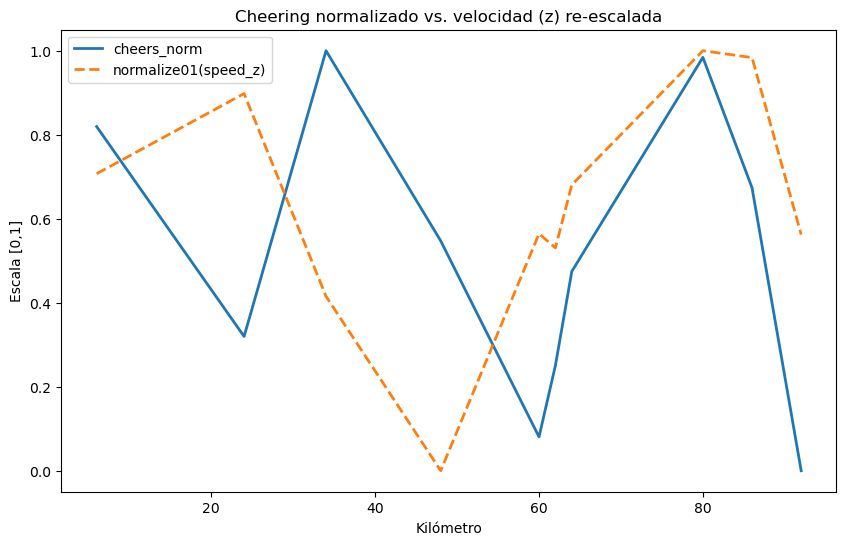

In [7]:
df_sorted = df.sort_values("km")

plt.figure(figsize=(10,6))
plt.plot(df_sorted["km"], normalize01(df_sorted["cheers_db"]),
         label="cheers_norm", lw=2)
plt.plot(df_sorted["km"], normalize01(standardize(df_sorted["speed_kmh"])),
         label="normalize01(speed_z)", lw=2, linestyle="--")
plt.xlabel("Kilómetro")
plt.ylabel("Escala [0,1]")
plt.title("Cheering normalizado vs. velocidad (z) re-escalada")
plt.legend()
plt.show()



A priori, no hay una correlación directa fuerte entre cheering y velocidad. Los picos de cheerign parecen estar más asociados a eventos puntuales (las zonas con más público), no tanto al ritmo real de la carrera.

### Discretización

En la carrera de drones queremos agrupar velocidades en categorías ( “lento / crucero / rápido / turbo”).  
Probamos tres métodos:

1. **Equal Width (EW):** divide en intervalos de mismo ancho.  
2. **Equal Frequency (EF):** divide por cuantiles (mismo nº de observaciones por intervalo).  
3. **Cortes manuales:** umbrales definidos por criterio externo.  


In [14]:
import pandas as pd
import sys
sys.path.append(r"c:\Users\usuario\OneDrive - alumni.unav.es\UPV\Software_Matematico_Estadistico\Python\permupack_python\permupack")
from perm_utils import discretizeEW, discretizeEF, discretize

# Aplicamos discretizaciones
res_ew = discretizeEW(speed_kmh, num_bins=4)
res_ef = discretizeEF(speed_kmh, num_bins=4)
res_manual = discretize(speed_kmh, [28, 32, 35])

res_ew = {
    "categorias": res_ew["categorias"],
    "puntos_corte": [round(v, 2) for v in res_ew["puntos_corte"]]
}

res_ef = {
    "categorias": res_ef["categorias"],
    "puntos_corte": [round(v, 2) for v in res_ef["puntos_corte"]]
}

# Crear el DataFrame
df_cats = pd.DataFrame({
    "km": checkpoints,
    "v_kmh": speed_kmh,  # sin redondear aquí
    "EW": res_ew["categorias"],
    "EF": res_ef["categorias"],
    "Manual": res_manual
})

df_cats.head(5)

,km,v_kmh,EW,EF,Manual
0,86,34.021226,3,3,2
1,80,34.184120,3,3,2
2,92,29.888587,2,1,1
3,24,33.183209,3,3,2
4,48,24.378798,0,0,0


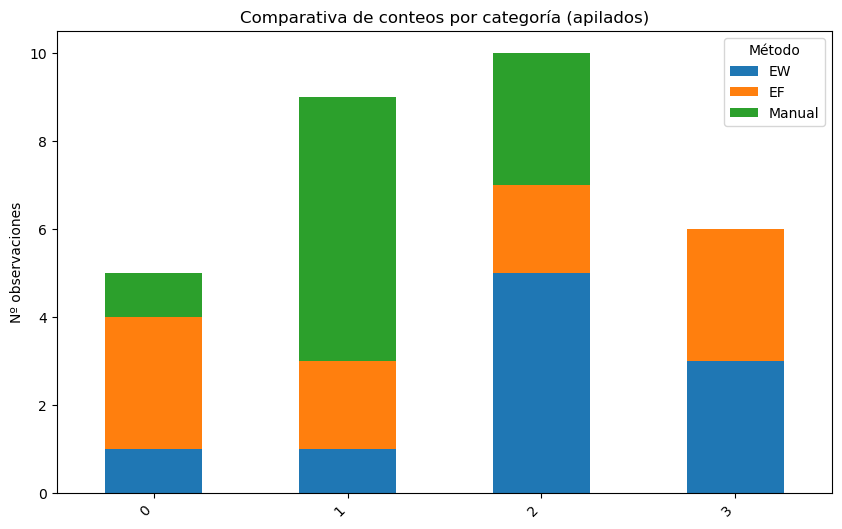

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

tab_ew = df_cats["EW"].value_counts().reindex(sorted(df_cats["EW"].unique()), fill_value=0)
tab_ef = df_cats["EF"].value_counts().reindex(sorted(df_cats["EF"].unique()), fill_value=0)
tab_mn = df_cats["Manual"].value_counts().reindex(sorted(df_cats["Manual"].unique()), fill_value=0)

counts = pd.DataFrame([tab_ew, tab_ef, tab_mn], index=["EW","EF","Manual"]).T.fillna(0)
counts.plot(kind="bar", stacked=True, figsize=(10, 6), color=["#1f77b4", "#ff7f0e", "#2ca02c"])
plt.title("Comparativa de conteos por categoría (apilados)")
plt.ylabel("Nº observaciones")
plt.xticks(rotation=45, ha="right")
plt.gca().yaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.legend(title="Método")
plt.show()

Por lo que se ve:

- Equal-Width (EW) distribuye más datos en las categorías altas (2 y 3).
- Equal-Frequency (EF) reparte de forma más balanceada entre 0, 2 y 3, pero menos en 1.
- Manual concentra muchas observaciones en la categoría intermedia (1), dejando vacía la última.

Se deja a criterio del analista de velocidades cuál de los tres métodos utilizar para caracterizar las velocidades de los drones en lento (0), crucero (1), rapido (2) y turbo (3).

### Entropía

La entropía es una herramienta estadística que nos permite medir la incertidumbre o la diversidad en la distribución de estas categorías. A través de este análisis, buscamos responder a la siguiente pregunta:

- ¿Cómo varía la diversidad de velocidades entre los diferentes métodos de discretización en la carrera de drones?

Si está cerca de **1 → distribución uniforme**, si está cerca de **0 → concentrado en una categoría**.


In [16]:
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(r"c:\Users\usuario\OneDrive - alumni.unav.es\UPV\Software_Matematico_Estadistico\Python\permupack_python\permupack")
from perm_utils import entropy

# Calcular entropía para cada método
H = df_cats[["EW", "EF", "Manual"]].apply(entropy)

# Número de categorías únicas para cada método
K = df_cats[["EW", "EF", "Manual"]].nunique()

# Entropía normalizada
Hn = H / np.log2(K)

# Mostrar resultados
pd.DataFrame({"H": H.round(3), "Hn": Hn.round(3)})


,H,Hn
EW,1.685,0.843
EF,1.971,0.985
Manual,1.295,0.817


Se observa que el método de discretización Equal Frequency (EF) no solo tiene la mayor entropía, sino que también maximiza la diversidad relativa de las categorías. Esto podría ser un indicativo de que el método EF es el más efectivo para representar las diferentes velocidades de los drones.

## 3. Mini-Festival

Creo que la carrera de drones ya ha dado para bastante. 
Ahora, porque me gusta hacer las cosas entretenidas y diferentes, pasemos a un nuevo escenario: un **mini-festival con seis bandas**.  

La idea no es solo tocar música , sino aprovechar este contexto para practicar técnicas estadísticas y de programación en Python:

El objetivo es usar este contexto para practicar:

1. **Permutaciones** → cómo reordenar y recuperar el orden original de un cartel.  
2. **Curvas ROC/AUC** → medir si un score distingue bien entre actuaciones que hicieron vibrar al público.  
3. **Correlaciones y Heatmaps** → explorar relaciones entre métricas (energía, popularidad, BPM, luces).  

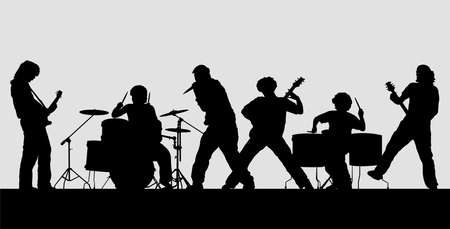

In [65]:
from IPython.display import Image
Image("images/minifestival.jpg")

### 3.4 Permutaciones

Imaginemos que tenemos este cartel inicial de 6 bandas.
Por motivos logísticos, la organización decide cambiar el orden.
En este apartado veremos cómo validar esa reordenación, cómo deshacerla (inversa) y cómo aplicar cambios adicionales (composición y swaps).


In [5]:
import numpy as np
import pandas as pd
import sys
sys.path.append(r"c:\Users\usuario\OneDrive - alumni.unav.es\UPV\Software_Matematico_Estadistico\Python\permupack_python\permupack")
from permupack.perm_utils import isPermutation, getRandomPermutation, getIdentityPermutation, __getPermutations
from permupack.Permutation import perm_parity, perm_cycles_named

# Cartel original
lineup = ["Alpha", "Blaze", "Comet", "Dynamo", "Echo", "Flux"]
n = len(lineup)
print("=== Cartel original ===")
print(pd.DataFrame({"Posición": np.arange(1, n+1), "Artista": lineup}), "\n")

# 1) Permutación aleatoria
p = getRandomPermutation(n)
lineup_new = np.array(lineup)[p]

print("=== Permutación aleatoria ===")
df_perm = pd.DataFrame({
    "Posición original": np.arange(1, n+1),
    "Artista original": lineup,
    "Posición nueva": p+1,
    "Artista nuevo": lineup_new
})
print(df_perm, "\n")

# 2) Inversa de la permutación
q = np.argsort(p)   # inversa
lineup_recovered = lineup_new[q]
print("¿Se recupera el original?:", np.all(np.array(lineup) == lineup_recovered), "\n")

# 3) Swap elemental (intercambiar posiciones 2 y 5 en la identidad)
swap_2_5 = np.arange(n)
swap_2_5[[1,4]] = swap_2_5[[4,1]]
print("=== Swap elemental (2 <-> 5) ===")
print("Índices swap:", swap_2_5+1, "\n")

# 4) Composición: primero p, luego swap
r = swap_2_5[p]
lineup_final = np.array(lineup)[r]

print("=== Composición (perm + swap) ===")
df_final = pd.DataFrame({
    "Posición original": np.arange(1, n+1),
    "Artista original": lineup,
    "Posición final": r+1,
    "Artista final": lineup_final
})
print(df_final, "\n")

# 5) Paridad de la permutación
res = perm_parity(r)
print("=== Paridad ===")
print(f"Inversiones: {res['inversions']} → Paridad: {res['parity']} (signo {res['sign']})\n")

# 6) Ciclos disjuntos
print("=== Ciclos disjuntos ===")
print("Ciclos:", perm_cycles_named(r, lineup), "\n")

# 7) Matriz de permutación
P = np.zeros((n,n), dtype=int)
for i in range(n):
    P[i, r[i]] = 1

print("=== Matriz de permutación ===")
print(P, "\n")

# Verificación de acción sobre vector
x = np.arange(1,n+1)
y_index = x[r]
y_mat = P @ x
print("¿Matriz equivale al índice?:", np.all(y_index == y_mat), "\n")

# 8) Swap en el lineup final (posiciones 3 y 6)
r2 = r.copy()
r2[[2,5]] = r2[[5,2]]
lineup_fine = np.array(lineup)[r2]

print("=== Swap extra (3 <-> 6 en lineup final) ===")
df_swap = pd.DataFrame({
    "Antes": lineup_final,
    "Después": lineup_fine
})
print(df_swap)


=== Cartel original ===
   Posición Artista
0         1   Alpha
1         2   Blaze
2         3   Comet
3         4  Dynamo
4         5    Echo
5         6    Flux 

=== Permutación aleatoria ===
   Posición original Artista original  Posición nueva Artista nuevo
0                  1            Alpha               1         Alpha
1                  2            Blaze               2         Blaze
2                  3            Comet               5          Echo
3                  4           Dynamo               4        Dynamo
4                  5             Echo               3         Comet
5                  6             Flux               6          Flux 

¿Se recupera el original?: True 

=== Swap elemental (2 <-> 5) ===
Índices swap: [1 5 3 4 2 6] 

=== Composición (perm + swap) ===
   Posición original Artista original  Posición final Artista final
0                  1            Alpha               1         Alpha
1                  2            Blaze               5      

Con estas operaciones pretendo demostrar que cualquier reordenación del cartel puede describirse y operar de forma equivalente como (a) un vector de índices r, (b) una descomposición en ciclos, o (c) una matriz de permutación P, y que todas producen el mismo resultado. Además, la inversa recupera el orden original y un swap es solo una composición adicional que puede cambiar la paridad de la permutación.

### 3.5 IO y Logging

Para el festival hemos recibido un CSV con la ficha técnica de cada banda: duración del set, BPM medio, energía en escenario, dB estimados, género, escenario y franja horaria.
Vamos a:

1. Leer el CSV con tipado automático (números como num/entero, categorías como factor).

2. Registrar pasos clave en un log con timestamp (trazabilidad).


In [59]:
import tempfile, datetime

# Datos simulados
bands = pd.DataFrame({
    "band": ["Alpha","Blaze","Comet","Dynamo","Echo","Flux"],
    "set_minutes": [40, 35, 50, 45, 30, 55],
    "bpm_mean": [128, 140, 110, 150, 95, 132],
    "energy": [7.5, 8.8, 6.1, 9.2, 5.5, 7.9],
    "db_peak": [98, 103, 95, 106, 92, 101],
    "genre": ["EDM","Rock","Indie","Metal","Acoustic","EDM"],
    "stage": ["A","B","A","B","A","B"],
    "slot": ["Early","Mid","Mid","Late","Early","Late"]
})

# Guardamos a CSV temporal
tmp_csv = tempfile.NamedTemporaryFile(delete=False, suffix=".csv").name
bands.to_csv(tmp_csv, index=False)

# Logging simple
log_path = tempfile.NamedTemporaryFile(delete=False, suffix=".log").name
with open(log_path, "w") as f:
    f.write(f"[{datetime.datetime.now()}] Guardado CSV simulado en {tmp_csv}\n")
    f.write(f"[{datetime.datetime.now()}] CSV leído con pandas.read_csv()\n")

# Lectura
df = pd.read_csv(tmp_csv)
with open(log_path, "r") as f:
    print("Log:\n", "".join(f.readlines()))


Log:
 [2025-09-28 13:31:37.067252] Guardado CSV simulado en C:\Users\usuario\AppData\Local\Temp\tmpzgqzvr62.csv
[2025-09-28 13:31:37.067252] CSV leído con pandas.read_csv()



### 3.6 ROC-AUC

Después del festival preguntamos al público si cada actuación les hizo vibrar (1 = sí, 0 = no).  

Con estos datos dibujamos una curva **ROC**:  
- Cada punto representa la capacidad de un score para separar positivos de negativos.  
- El **AUC** mide la calidad de la predicción.0.5 es azar, un rango 0.7-0.8 consideraremos aceptable y por encima de 0.9 es excelente la actuación


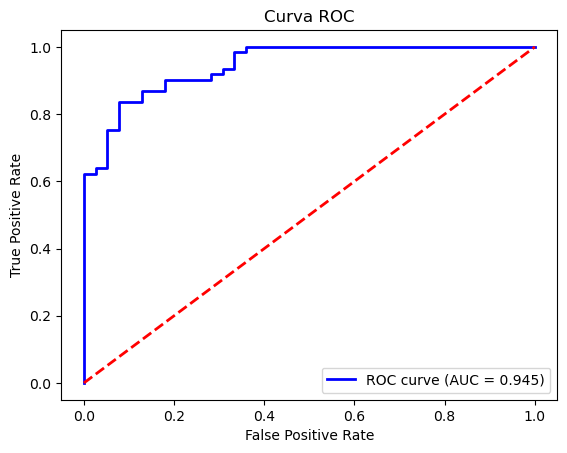

AUC obtenido: 0.9453551912568305


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from permupack.perm_plotting import dibujar_roc

n = 100
# Variable real: 1 = vibró con la banda, 0 = no vibró
real = np.random.binomial(1, 0.6, size=n)

# Score correlacionado con "real" para que AUC > 0.5
prob = real * np.random.uniform(0.4, 1, size=n) + (1 - real) * np.random.uniform(0, 0.6, size=n)

A_festival = pd.DataFrame({"real": real, "prob": prob})

roc_info = dibujar_roc(A_festival, col_real="real", col_prob="prob")

print("AUC obtenido:", roc_info["auc"])


Lo que se ve es que el modelo tiene un 91% de probabilidad de asignar un score mayor a un individuo positivo que a uno negativo, elegido al azar. A nivel práctico, eso significa que el sistema predice bastante bien qué público vibra con cada banda.

### 3.7 Correlaciones
Ahora queremos explorar relaciones lineales entre variables numéricas (energia, popularidad, Beats Per Minute (bpm) e intensidad de las luces). Un mapa de correlación nos ayuda a detectar asociaciones (positivas/negativas) que podrían guiar decisiones de mezcla de sonido o de orden en el cartel.
Más allá del “vibró o no vibró”, también medimos para cada banda algunas características:

- Energía escénica (0–100)
- Popularidad previa (40–95, estimada por redes sociales)
- BPM promedio (80–160)
- Intensidad de luces (50–100)
  
Con estas variables numéricas, calculamos la matriz de correlaciones para ver qué está relacionado con qué:

- Una correlación positiva fuerte indica que ambas variables tienden a crecer juntas (ej. energía y luces).
- Una correlación negativa indica que cuando una sube, la otra baja.
- Un valor cercano a 0 indica ausencia de relación lineal.

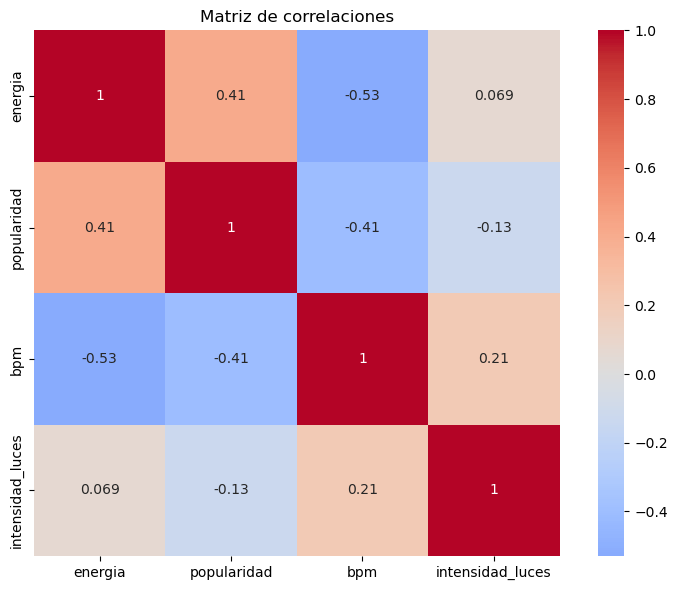

Matriz de correlaciones:
                   energia  popularidad       bpm  intensidad_luces
energia           1.000000     0.410961 -0.529930          0.068931
popularidad       0.410961     1.000000 -0.410284         -0.126488
bpm              -0.529930    -0.410284  1.000000          0.210156
intensidad_luces  0.068931    -0.126488  0.210156          1.000000


In [4]:
# ---------------------------
# Correlaciones · Mini-festival
# ---------------------------
import seaborn as sns
from permupack.perm_plotting import dibujar_correlaciones

# Bandas
bandas = ["The Rockets", "Synth Waves", "Indie Roots",
          "Metal Storm", "Jazz Vibes", "Pop Lights"]

# Dataset simulado
np.random.seed(42)  # opcional para reproducibilidad
df_band = pd.DataFrame({
    "energia": np.random.uniform(60, 100, size=6),
    "popularidad": np.random.uniform(40, 95, size=6),
    "bpm": np.random.uniform(80, 160, size=6),
    "intensidad_luces": np.random.uniform(50, 100, size=6)
}, index=bandas)

# Dibujar correlaciones con tu función
M_band = dibujar_correlaciones(df_band)

print("Matriz de correlaciones:")
print(M_band)


Por tanto, en este mini-festival, la clave del éxito parece ser energía + popularidad, mientras que subir mucho el tempo (BPM) podría incluso perjudicar la percepción. Las luces no son determinantes en la correlación.